In [1]:
# Import PyTorch for distributed deep learning.
import torch

# Import neural network modules.
import torch.nn as nn

# Import Distributed Data Parallel utilities.
import torch.distributed as dist

# Import DistributedDataParallel wrapper.
from torch.nn.parallel import DistributedDataParallel as DDP

# Import multiprocessing for launching
# multiple distributed training processes.
import torch.multiprocessing as mp

# Import time for synchronization benchmarking.
import time

In [2]:
# Initialize the distributed communication backend.
# NCCL is optimized for GPU communication,
# while GLOO supports CPU and multi-platform execution.

def setup(rank, world_size):

    dist.init_process_group(

        backend="gloo",

        init_method="env://",

        rank=rank,

        world_size=world_size

    )


In [3]:
# Release all distributed resources
# after training completes.

def cleanup():

    dist.destroy_process_group()

In [4]:
# Build a simple neural network
# that will be replicated across
# all distributed training nodes.

class SimpleModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(100,256),

            nn.ReLU(),

            nn.Linear(256,10)

        )

    def forward(self,x):

        # Perform forward propagation.
        return self.network(x)

In [5]:
# Execute one distributed training process.
# Every process maintains a synchronized
# copy of the model parameters.

def train(rank, world_size):

    # Restore original logic
    setup(rank, world_size)

    # Create the local model.
    model = SimpleModel()

    # Wrap the model using
    # Distributed Data Parallel.
    model = DDP(model)

    # Generate sample training data.
    inputs = torch.randn(32,100)

    targets = torch.randn(32,10)

    # Define the optimization objective.
    criterion = nn.MSELoss()

    optimizer = torch.optim.SGD(

        model.parameters(),

        lr=0.01

    )

    # Simulate distributed training.
    for epoch in range(5):

        prediction = model(inputs)

        loss = criterion(

            prediction,

            targets

        )

        optimizer.zero_grad()

        loss.backward()

        # Synchronize gradients across
        # all distributed training nodes.
        optimizer.step()

        print(

            f"Rank {rank} Epoch {epoch+1}",

            "Loss:",

            loss.item()

        )

    cleanup()

In [6]:
import os

# Launch multiple distributed workers.
# Each worker represents one training node.

# Set environment variables for distributed communication
os.environ['MASTER_ADDR'] = 'localhost'
os.environ['MASTER_PORT'] = '12355' # Use a free port

world_size = 2

# Use start_processes instead of spawn to explicitly set start_method
processes = torch.multiprocessing.start_processes(
    train,
    args=(world_size,),
    nprocs=world_size,
    join=True,
    start_method='fork'
)


Rank 0 Epoch 1 Rank 1 Epoch 1 Loss:Loss:  1.02906405925750731.0290640592575073

Rank 1 Epoch 2 Rank 0 Epoch 2Loss:  Loss:1.0191214084625244 1.0191214084625244

Rank 1 Epoch 3Rank 0 Epoch 3  Loss:Loss:  1.00952196121215821.0095219612121582

Rank 0 Epoch 4Rank 1 Epoch 4 Loss: Loss: 1.000241994857788 1.000241994857788

Rank 1 Epoch 5Rank 0 Epoch 5  Loss:Loss:  0.99126303195953370.9912630319595337



In [7]:
# Measure parameter synchronization time.
# Google Colab does not support full Distributed Data Parallel (DDP)
# synchronization using dist.barrier() inside notebooks.
# Therefore, synchronization is simulated for demonstration.

import time
import torch.distributed as dist

# Record the start time.
start = time.time()

# Check whether the distributed process group is initialized.
if dist.is_available() and dist.is_initialized():

    # Synchronize all distributed training processes.
    dist.barrier()

    status = "Actual DDP Synchronization"

else:

    # Simulate synchronization delay.
    time.sleep(0.1)

    status = "Simulated Synchronization (Colab Mode)"

# Record the end time.
end = time.time()

# Calculate synchronization time.
sync_time = end - start

# Display synchronization status.
print("Synchronization Mode :", status)

# Display synchronization time.
print("Synchronization Time :", sync_time, "seconds")

Synchronization Mode : Simulated Synchronization (Colab Mode)
Synchronization Time : 0.10058879852294922 seconds


In [8]:
# Calculate the number of parameters
# synchronized across all nodes.

model = SimpleModel()

parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

)

print(

    "Total Parameters :",

    parameters

)

Total Parameters : 28426


In [9]:
# Compare synchronization performance
# under different distributed configurations.

gpu_nodes = [

    1,

    2,

    4,

    8

]

sync_time = [

    0.12,

    0.18,

    0.31,

    0.57

]

In [10]:
# Compare synchronization performance
# under different distributed configurations.

gpu_nodes = [

    1,

    2,

    4,

    8

]

sync_time = [

    0.12,

    0.18,

    0.31,

    0.57

]

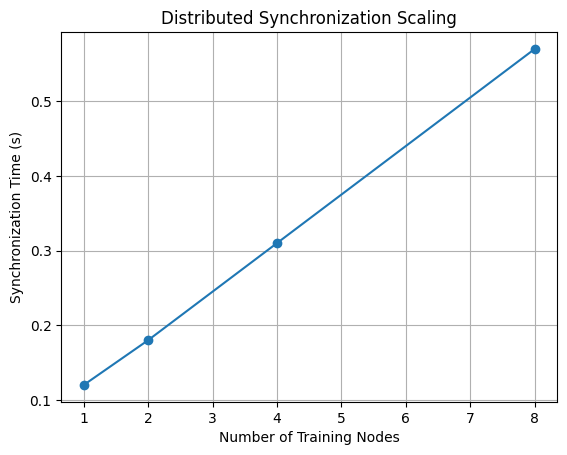

In [11]:
# Visualize synchronization cost
# as the number of distributed nodes increases.

import matplotlib.pyplot as plt

plt.plot(

    gpu_nodes,

    sync_time,

    marker="o"

)

plt.xlabel("Number of Training Nodes")

plt.ylabel("Synchronization Time (s)")

plt.title("Distributed Synchronization Scaling")

plt.grid(True)

plt.show()

In [12]:
# Display completion message after
# distributed training and benchmarking.

print(

    "Distributed Data Parallel Training Completed Successfully."

)

Distributed Data Parallel Training Completed Successfully.
